## Assignment: Image recognition
- Alumno 1:
- Alumno 2:
- Alumno 3:

The goals of the assignment are:
* Develop proficiency in using Tensorflow/Keras for training Neural Nets (NNs).
* Put into practice the acquired knowledge to optimize the parameters and architecture of a feedforward Neural Net (ffNN), in the context of an image recognition problem.
* Put into practice NNs specially conceived for analysing images. Design and optimize the parameters of a Convolutional Neural Net (CNN) to deal with previous task.
* Train popular architectures from scratch (e.g., GoogLeNet, VGG, ResNet, ...), and compare the results with the ones provided by their pre-trained versions using transfer learning.

Follow the link below to download the classification data set  “xview_recognition”: [https://drive.upm.es/s/2DDPE2zHw5dbM3G](https://drive.upm.es/s/2DDPE2zHw5dbM3G)

In [1]:
import sys
from pathlib import Path

import tensorflow as tf

PROJECT_DIR = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "common" / "ffnn_challenge_utils.py").exists()
)
sys.path.insert(0, str(PROJECT_DIR / "common"))

from ffnn_challenge_utils import (
    CATEGORIES,
    DATASET_DIR,
    GenericImage,
    GenericObject,
    TEST_IMAGES_DIR,
    TRAIN_ANNOTATIONS_PATH,
    build_training_annotations,
    draw_confusion_matrix,
    image_generator as generator_images,
    load_annotations,
    load_geoimage,
    plot_training_history,
    plot_precision_recall_curves,
)

print(tf.config.list_physical_devices('GPU'))

# EXPERIMENT 10: use a dedicated output directory.
# Original experiment_09 directory retained for traceability:
# EXPERIMENT_DIR = PROJECT_DIR / "experiments" / "fnn_challenge" / "experiment_09"
EXPERIMENT_DIR = PROJECT_DIR / "experiments" / "fnn_challenge" / "experiment_10"
EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)
categories = CATEGORIES

2026-10-04 19:47:10.594407: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-10-04 19:47:10.631071: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-10-04 19:47:10.631093: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-10-04 19:47:10.633060: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-10-04 19:47:10.644103: I tensorflow/core/platform/cpu_feature_guar

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2026-10-04 19:47:11.977345: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-10-04 19:47:12.073866: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-10-04 19:47:12.073919: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


In [2]:
# GenericObject and GenericImage are provided by ffnn_challenge_utils.

In [3]:
categories = CATEGORIES

In [4]:
# load_geoimage is provided by ffnn_challenge_utils.

#### Training
Design and train a ffNN to deal with the “xview_recognition” classification task.

In [5]:
import json

json_data = load_annotations(TRAIN_ANNOTATIONS_PATH)

In [6]:
counts = dict.fromkeys(categories.values(), 0)
anns = build_training_annotations(json_data)
for ann in anns:
    for obj in ann.objects:
        counts[obj.category] += 1
print(counts)

{'Cargo plane': 635, 'Small car': 3324, 'Bus': 1768, 'Truck': 2210, 'Motorboat': 1069, 'Fishing vessel': 706, 'Dump truck': 1236, 'Excavator': 789, 'Building': 3594, 'Helipad': 111, 'Storage tank': 1469, 'Shipping container': 1523, 'Pylon': 312}


In [7]:
from sklearn.model_selection import train_test_split

anns_train, anns_valid = train_test_split(anns, test_size=0.1, random_state=1, shuffle=True)
print('Number of training images: ' + str(len(anns_train)))
print('Number of validation images: ' + str(len(anns_valid)))

Number of training images: 16871
Number of validation images: 1875


In [8]:
# Load architecture
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Flatten

# EXPERIMENT 10: add one Dense(64) layer before the output.
# Original experiment_09 architecture retained for traceability:
# print('Load model')
# model = Sequential()
# model.add(Flatten(input_shape=(224, 224, 3)))
# model.add(Dense(512, activation='relu'))
# model.add(Dense(256, activation='relu'))
# model.add(Dense(128, activation='relu'))
# model.add(Dense(len(categories), activation='softmax'))
# model.summary()

print('Load model')
model = Sequential()
model.add(Flatten(input_shape=(224, 224, 3)))
model.add(Dense(512, activation='relu'))
model.add(Dense(256, activation='relu'))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(len(categories), activation='softmax'))
model.summary()

Load model


2026-10-04 19:47:12.430680: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-10-04 19:47:12.430775: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-10-04 19:47:12.430824: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-10-04 19:47:12.559960: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-10-04 19:47:12.560046: I external/local_xla/xla/stream_executor

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 150528)            0         
                                                                 
 dense (Dense)               (None, 512)               77070848  
                                                                 
 dense_1 (Dense)             (None, 256)               131328    
                                                                 
 dense_2 (Dense)             (None, 128)               32896     
                                                                 
 dense_3 (Dense)             (None, 64)                8256      
                                                                 
 dense_4 (Dense)             (None, 13)                845       
                                                                 
Total params: 77244173 (294.66 MB)
Trainable params: 772

In [9]:
from tensorflow.keras.optimizers import SGD

# EXPERIMENT 08: test a larger SGD learning rate after experiment_07.
# Original experiment_07 optimizer retained for traceability:
# opt = SGD(learning_rate=1e-4, momentum=0.9, nesterov=True, clipnorm=1.0)
opt = SGD(learning_rate=3e-4, momentum=0.9, nesterov=True, clipnorm=1.0)
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

In [10]:
from tensorflow.keras.callbacks import TerminateOnNaN, EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# EXPERIMENT 10: save the best checkpoint inside experiment_10.
# Original experiment_09 line retained for traceability:
# model_checkpoint = ModelCheckpoint(str(EXPERIMENT_DIR / 'model.keras'), monitor='val_accuracy', verbose=1, save_best_only=True)
model_checkpoint = ModelCheckpoint(str(EXPERIMENT_DIR / 'model.keras'), monitor='val_accuracy', verbose=1, save_best_only=True)
reduce_lr = ReduceLROnPlateau('val_accuracy', factor=0.1, patience=10, verbose=1)
early_stop = EarlyStopping('val_accuracy', patience=40, verbose=1)
terminate = TerminateOnNaN()
callbacks = [model_checkpoint, reduce_lr, early_stop, terminate]

In [11]:
# generator_images is provided by ffnn_challenge_utils.

In [12]:
# Generate the list of objects from annotations
objs_train = [(ann.filename, obj) for ann in anns_train for obj in ann.objects]
objs_valid = [(ann.filename, obj) for ann in anns_valid for obj in ann.objects]
# Generators
# EXPERIMENT 09: reduce batch size to test generalization.
# Original experiment_08 batch size retained for traceability:
# batch_size = 32 # Tamaño de batch incrementado
batch_size = 16
train_generator = generator_images(objs_train, batch_size, do_shuffle=True)
valid_generator = generator_images(objs_valid, batch_size, do_shuffle=False)

Training model
Epoch 1/100


2026-10-04 19:47:13.715045: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-10-04 19:47:14.091865: I external/local_xla/xla/service/service.cc:168] XLA service 0x7222a502dc90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-10-04 19:47:14.091901: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 4070 Ti, Compute Capability 8.9
2026-10-04 19:47:14.100867: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
I0000 00:00:1791136034.139577  286349 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1054/1055 [============================>.] - ETA: 0s - loss: 5.7838 - accuracy: 0.2429
Epoch 1: val_accuracy improved from -inf to 0.31200, saving model to /home/german/master-ia/computer-vision/muia-cv-project/PROJECT/experiments/fnn_challenge/experiment_10/model.keras
1055/1055 [==============================] - 32s 29ms/step - loss: 5.7824 - accuracy: 0.2430 - val_loss: 2.5985 - val_accuracy: 0.3120 - lr: 3.0000e-04
Epoch 2/100
1054/1055 [============================>.] - ETA: 0s - loss: 2.1498 - accuracy: 0.3574
Epoch 2: val_accuracy improved from 0.31200 to 0.33387, saving model to /home/german/master-ia/computer-vision/muia-cv-project/PROJECT/experiments/fnn_challenge/experiment_10/model.keras
1055/1055 [==============================] - 30s 29ms/step - loss: 2.1495 - accuracy: 0.3574 - val_loss: 2.3415 - val_accuracy: 0.3339 - lr: 3.0000e-04
Epoch 3/100
1054/1055 [============================>.] - ETA: 0s - loss: 1.8730 - accuracy: 0.4049
Epoch 3: val_accuracy improved from 0.33

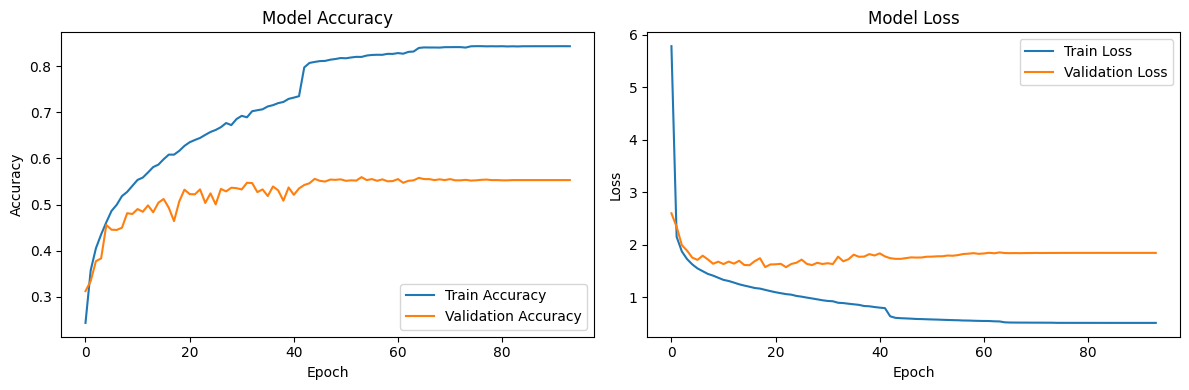

In [13]:
import math
import numpy as np

print('Training model')
epochs = 100 # Incrementado para aprovechar el EarlyStopping
train_steps = math.ceil(len(objs_train)/batch_size)
valid_steps = math.ceil(len(objs_valid)/batch_size)
h = model.fit(train_generator, steps_per_epoch=train_steps, validation_data=valid_generator, validation_steps=valid_steps, epochs=epochs, callbacks=callbacks, verbose=1)
# Best validation model
best_idx = int(np.argmax(h.history['val_accuracy']))
best_value = np.max(h.history['val_accuracy'])
print('Best validation model: epoch ' + str(best_idx+1), ' - val_accuracy ' + str(best_value))

# EXPERIMENT 10: reproduce experiment_05 training-history plots.
plot_training_history(h.history)

#### Validation
Compute validation metrics.

In [14]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

# draw_confusion_matrix is provided by ffnn_challenge_utils.

In [15]:
import numpy as np

model.load_weights(str(EXPERIMENT_DIR / "model.keras"))
y_true, y_pred, y_prob = [], [], []
for ann in anns_valid:
    # Load image
    image = load_geoimage(ann.filename)
    for obj_pred in ann.objects:
        # Generate prediction
        warped_image = np.expand_dims(image, 0)
        predictions = model.predict(warped_image, verbose=0)
        # Save prediction
        pred_category = list(categories.values())[np.argmax(predictions)]
        pred_score = np.max(predictions)
        y_true.append(obj_pred.category)
        y_pred.append(pred_category)
        y_prob.append(predictions[0])

y_prob = np.array(y_prob)

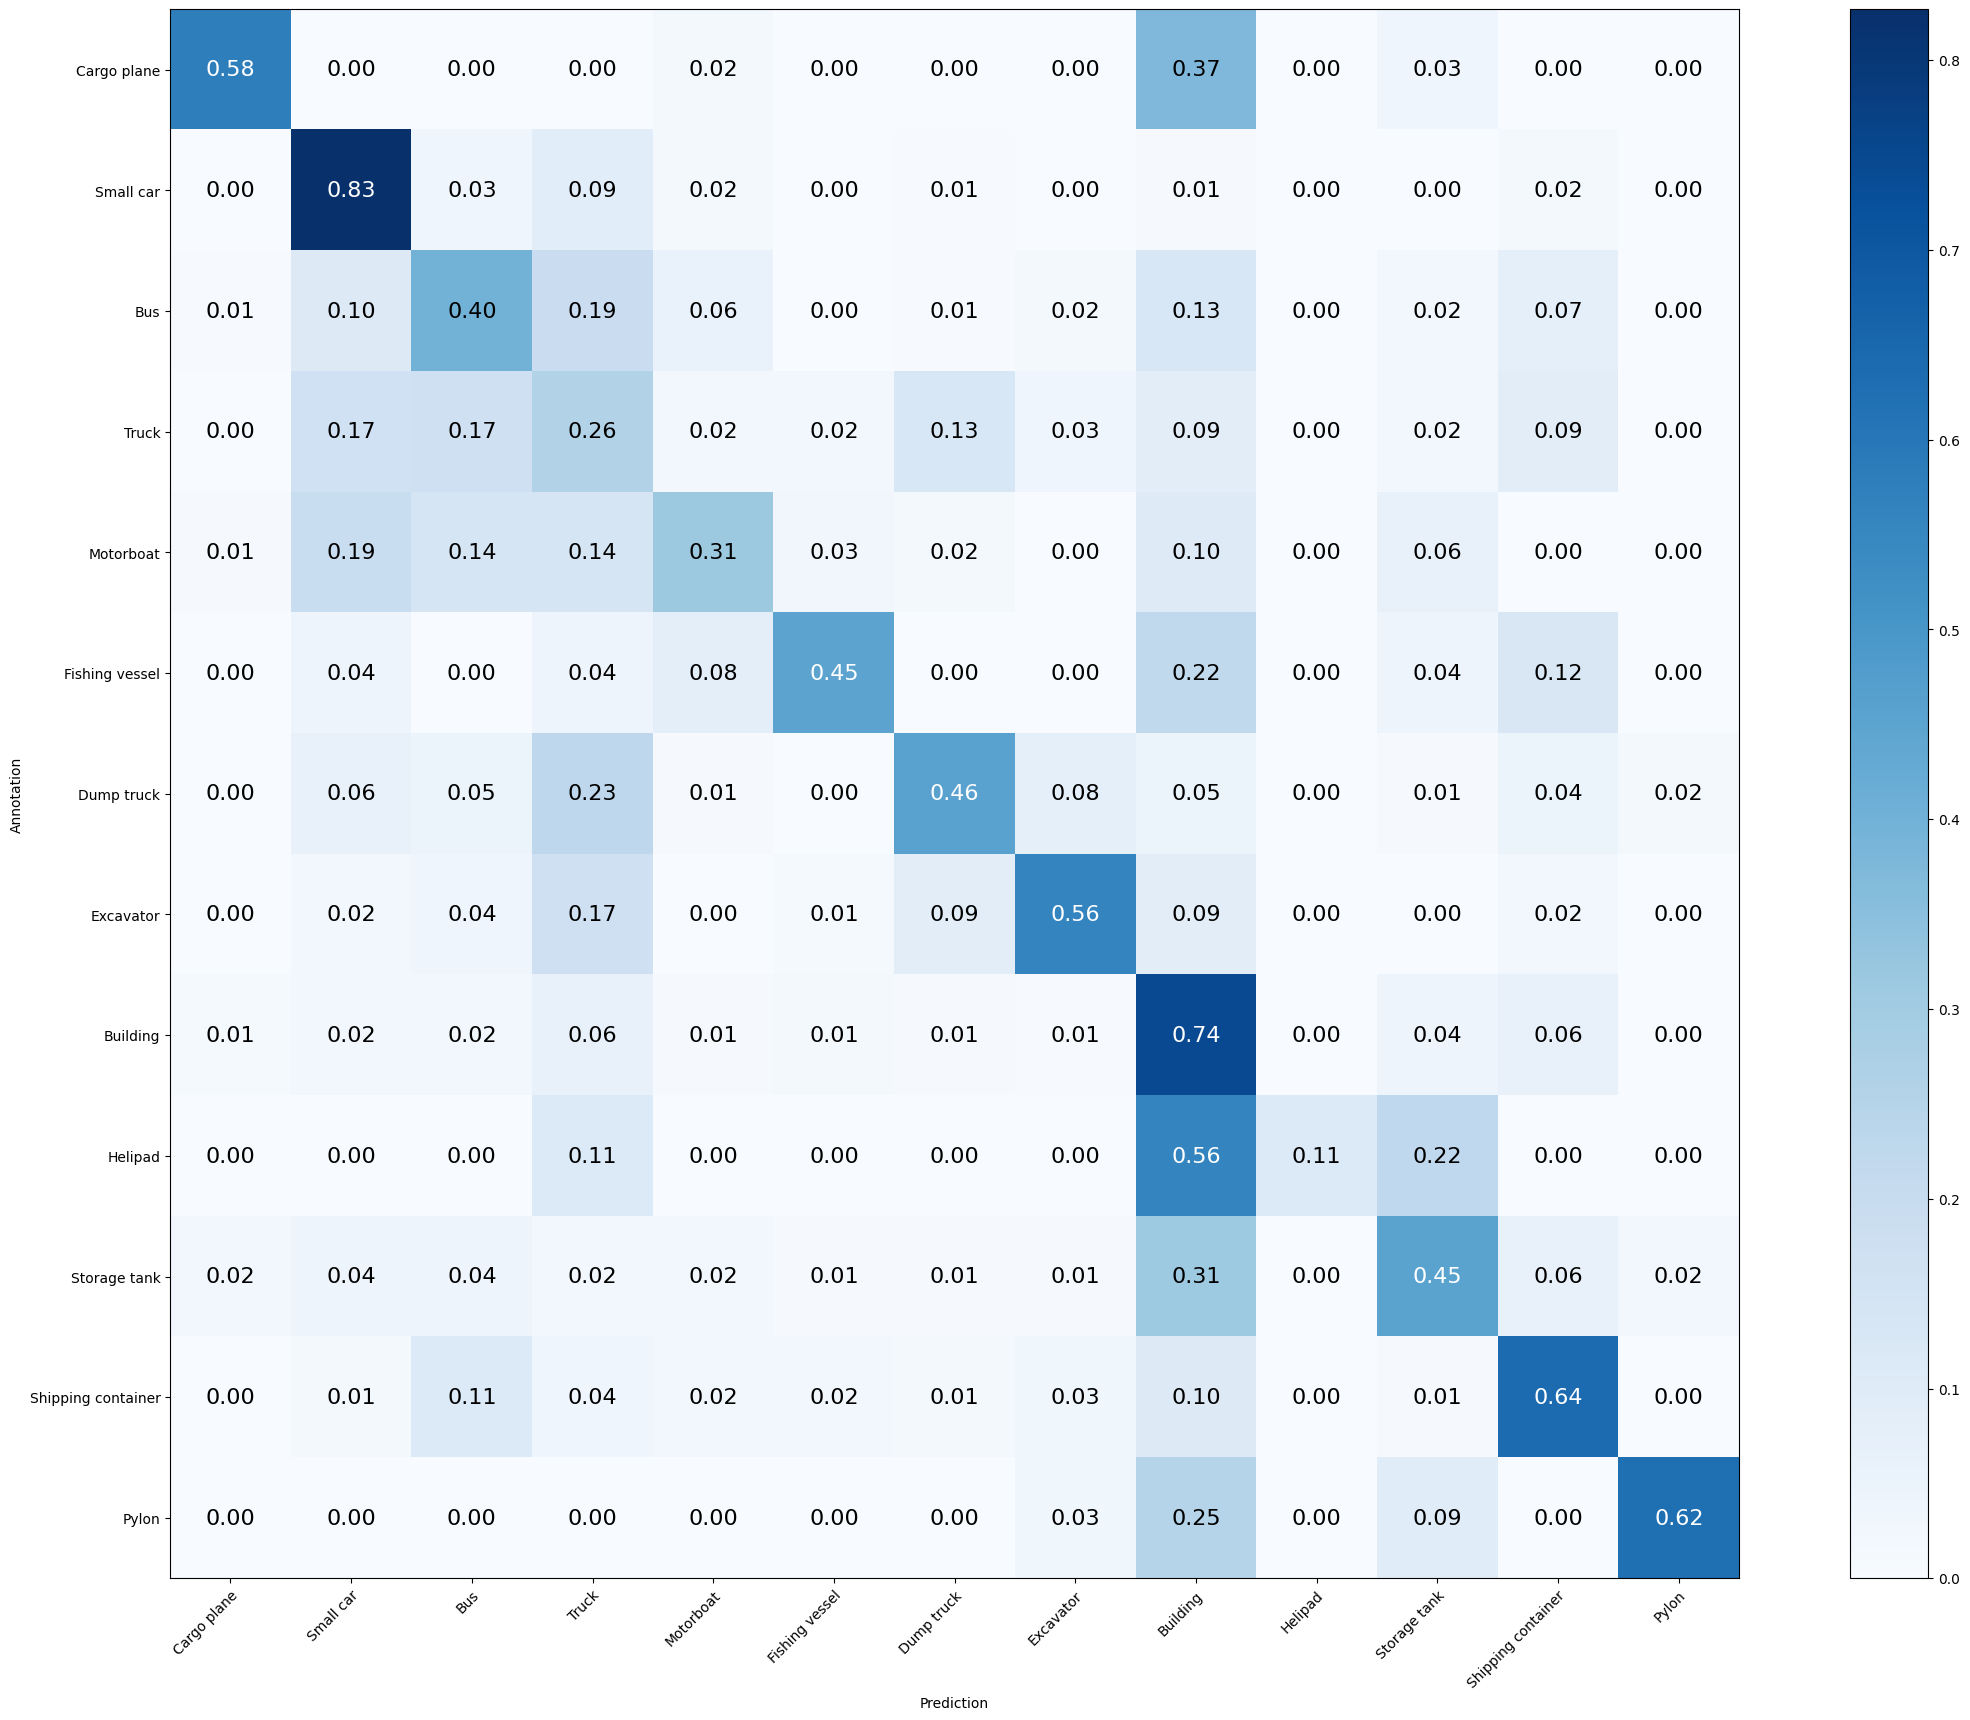

In [16]:
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=list(categories.values()))
draw_confusion_matrix(cm, categories)

In [17]:
import numpy as np

# Compute the accuracy
correct_samples_class = np.diag(cm).astype(float)
total_samples_class = np.sum(cm, axis=1).astype(float)
total_predicts_class = np.sum(cm, axis=0).astype(float)
print('Mean Accuracy: %.3f%%' % (np.sum(correct_samples_class) / np.sum(total_samples_class) * 100))
acc = correct_samples_class / np.maximum(total_samples_class, np.finfo(np.float64).eps)
print('Mean Recall: %.3f%%' % (acc.mean() * 100))
acc = correct_samples_class / np.maximum(total_predicts_class, np.finfo(np.float64).eps)
print('Mean Precision: %.3f%%' % (acc.mean() * 100))
for idx in range(len(categories)):
    # True/False Positives (TP/FP) refer to the number of predicted positives that were correct/incorrect.
    # True/False Negatives (TN/FN) refer to the number of predicted negatives that were correct/incorrect.
    tp = cm[idx, idx]
    fp = sum(cm[:, idx]) - tp
    fn = sum(cm[idx, :]) - tp
    tn = sum(np.delete(sum(cm) - cm[idx, :], idx))
    # True Positive Rate: proportion of real positive cases that were correctly predicted as positive.
    recall = tp / np.maximum(tp+fn, np.finfo(np.float64).eps)
    # Precision: proportion of predicted positive cases that were truly real positives.
    precision = tp / np.maximum(tp+fp, np.finfo(np.float64).eps)
    # True Negative Rate: proportion of real negative cases that were correctly predicted as negative.
    specificity = tn / np.maximum(tn+fp, np.finfo(np.float64).eps)
    # Dice coefficient refers to two times the intersection of two sets divided by the sum of their areas.
    # Dice = 2 |A∩B| / (|A|+|B|) = 2 TP / (2 TP + FP + FN)
    f1_score = 2 * ((precision * recall) / np.maximum(precision+recall, np.finfo(np.float64).eps))
    print('> %s: Recall: %.3f%% Precision: %.3f%% Specificity: %.3f%% Dice: %.3f%%' % (list(categories.values())[idx], recall*100, precision*100, specificity*100, f1_score*100))

Mean Accuracy: 55.947%
Mean Recall: 49.268%
Mean Precision: 60.728%
> Cargo plane: Recall: 57.627% Precision: 79.070% Specificity: 99.504% Dice: 66.667%
> Small car: Recall: 82.675% Precision: 71.768% Specificity: 93.079% Dice: 76.836%
> Bus: Recall: 39.655% Precision: 39.655% Specificity: 93.827% Dice: 39.655%
> Truck: Recall: 25.726% Precision: 28.972% Specificity: 90.698% Dice: 27.253%
> Motorboat: Recall: 31.193% Precision: 47.887% Specificity: 97.905% Dice: 37.778%
> Fishing vessel: Recall: 45.205% Precision: 63.462% Specificity: 98.946% Dice: 52.800%
> Dump truck: Recall: 45.763% Precision: 52.427% Specificity: 97.211% Dice: 48.869%
> Excavator: Recall: 55.556% Precision: 61.644% Specificity: 98.439% Dice: 58.442%
> Building: Recall: 74.380% Precision: 59.735% Specificity: 87.963% Dice: 66.258%
> Helipad: Recall: 11.111% Precision: 100.000% Specificity: 100.000% Dice: 20.000%
> Storage tank: Recall: 45.395% Precision: 61.062% Specificity: 97.446% Dice: 52.075%
> Shipping containe

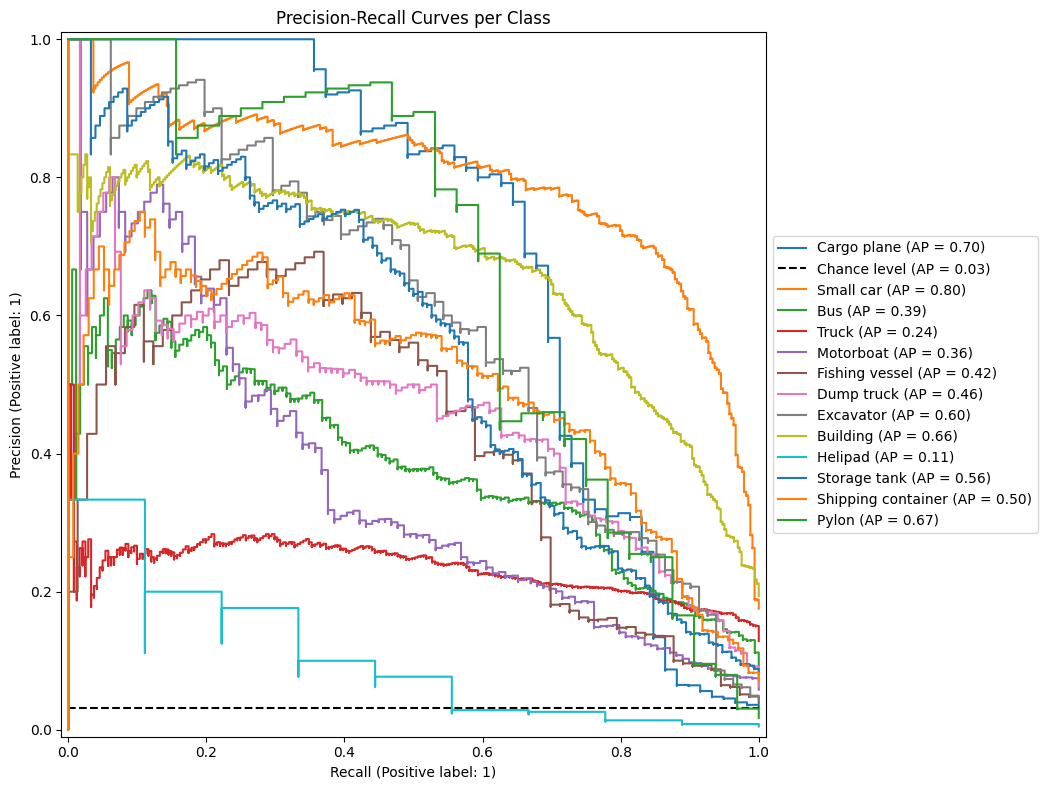

In [18]:
# EXPERIMENT 10: reproduce experiment_05 precision-recall curves.
plot_precision_recall_curves(y_true, y_prob, categories)

#### Testing
Try to improve the results provided in the competition.

In [19]:
import os
import numpy as np

anns = []
for (dirpath, dirnames, filenames) in os.walk(TEST_IMAGES_DIR):
    for filename in filenames:
        relative_directory = Path(dirpath).relative_to(DATASET_DIR).as_posix()
        image = GenericImage(relative_directory + '/' + filename)
        image.tile = np.array([0, 0, 224, 224])
        obj = GenericObject()
        obj.bb = (0, 0, 224, 224)
        obj.category = Path(dirpath).name
        image.add_object(obj)
        anns.append(image)
print('Number of testing images: ' + str(len(anns)))

Number of testing images: 2365


In [20]:
import numpy as np

model.load_weights(str(EXPERIMENT_DIR / "model.keras"))
predictions_data = {"images": {}, "annotations": {}}
for idx, ann in enumerate(anns):
    image_data = {"image_id": ann.filename.split('/')[-1], "filename": ann.filename, "width": int(ann.tile[2]), "height": int(ann.tile[3])}
    predictions_data["images"][idx] = image_data
    # Load image
    image = load_geoimage(ann.filename)
    for obj_pred in ann.objects:
        # Generate prediction
        warped_image = np.expand_dims(image, 0)
        predictions = model.predict(warped_image, verbose=0)
        # Save prediction
        pred_category = list(categories.values())[np.argmax(predictions)]
        pred_score = np.max(predictions)
        annotation_data = {"image_id": ann.filename.split('/')[-1], "category_id": pred_category, "bbox": [int(x) for x in obj_pred.bb]}
        predictions_data["annotations"][idx] = annotation_data

In [21]:
with open(EXPERIMENT_DIR / "prediction.json", "w") as outfile:
    json.dump(predictions_data, outfile)